The following code helps you to load and visualize the data (skeleton) in 3D xyz coordinates.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
plt.style.use('seaborn-v0_8-poster')

#filename and folder to plot
fname= "walking_1"
folder =  "/content/drive/MyDrive/AMATH482HW2_train"

location_name=os.path.join(folder,fname+".npy")
vals = np.load(location_name)
xyz = np.reshape( vals[:,:], (38,3,-1) )


print(xyz.shape)

#define the root joint and scaling of the values
r = 1000
xroot, yroot, zroot = xyz[0,0,0], xyz[0,0,1], xyz[0,0,2]

#define the connections between the joints (skeleton)
I = np.array(
        [1, 2, 3, 4, 5, 6, 1, 8, 9, 10, 11, 12, 1, 14, 15, 16, 17, 18, 19, 16, 21, 22, 23, 25, 26, 24, 28, 16, 30, 31,
         32, 33, 34, 35, 33, 37]) - 1
J = np.array(
        [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32,
         33, 34, 35, 36, 37, 38]) - 1


(38, 3, 100)


In [ ]:
# plot the skeleton accroding to joints (each plot is png image in anim folder)
os.makedirs("anim", exist_ok=True)
for tind in range(1,xyz.shape[2]):

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    for ijind in range(0,I.shape[0]):
        xline = np.array([xyz[I[ijind],0,tind], xyz[J[ijind],0,tind]])
        yline = np.array([xyz[I[ijind],1,tind], xyz[J[ijind],1,tind]])
        zline = np.array([xyz[I[ijind],2,tind], xyz[J[ijind],2,tind]])
        # use plot if you'd like to plot skeleton with lines
        ax.plot(xline,yline,zline)

    # use scatter if you'd like to plot all points without lines
    # ax.scatter(xyz[:,0,tind],xyz[:,1,tind],xyz[:,2,tind], c = 'r', s = 50)

    ax.set_xlim([-r+xroot, r+xroot])
    ax.set_zlim([-r+zroot, r+zroot])
    ax.set_ylim([-r+yroot, r+yroot])

    plt.savefig('anim/'+f"{tind}.png")
    plt.close()

# when plotting a single sample (the skeleton can simply be plotted without saving an image)
#     plt.draw()
#     plt.pause(.001)
#     plt.show()



# save the animated plot as a gif in anim folder
from PIL import Image

images = [Image.open('anim/'+f"{n}.png") for n in range(1,xyz.shape[2])]
images[0].save('anim/'+fname+'.gif', save_all=True, append_images=images[1:], duration=30, loop=0)

# remove ploted png images
for n in range(1,xyz.shape[2]):
    os.remove('anim/'+f"{n}.png")


(114, 1500)


Text(0.5, 1.0, 'PCA Cumulative Energy')

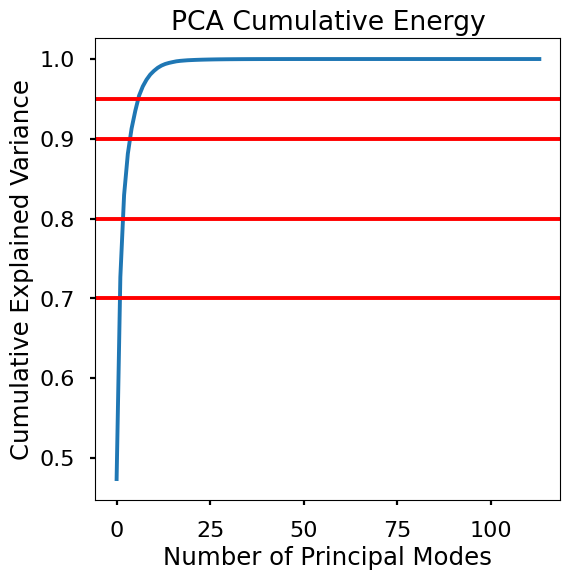

In [ ]:
from sklearn.decomposition import PCA
# Task 1
# Compile all train samples into a matrix 𝑋𝑡𝑟𝑎𝑖𝑛 and apply PCA such that the PCA modes are spatial
# modes and the coefficients are time-dependent coefficients. Investigate how many PCA spatial modes
# you need to keep to approximate 𝑋𝑡𝑟𝑎𝑖𝑛 up to 70%, 80% , 90% , 95% in Frobenius norm. Plot the
# cumulative energy to justify your results.

files = [file_name for file_name in os.listdir(folder) if file_name.endswith(".npy")]
num_files = len(files)
X_train = np.zeros((114, 100 * num_files))
column = 0
for file_name in files:
    aux_vals = np.load(os.path.join(folder,file_name))
    X_train[:, column:column+100] = aux_vals
    column += 100
print(X_train.shape)
pca = PCA()
pca.fit(X_train.T)

cumulative_energy = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,6))
plt.plot(cumulative_energy)
for i in [0.7, 0.8, 0.9, 0.95]:
  plt.axhline(y=i, color='r')
plt.xlabel("Number of Principal Modes")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Energy")


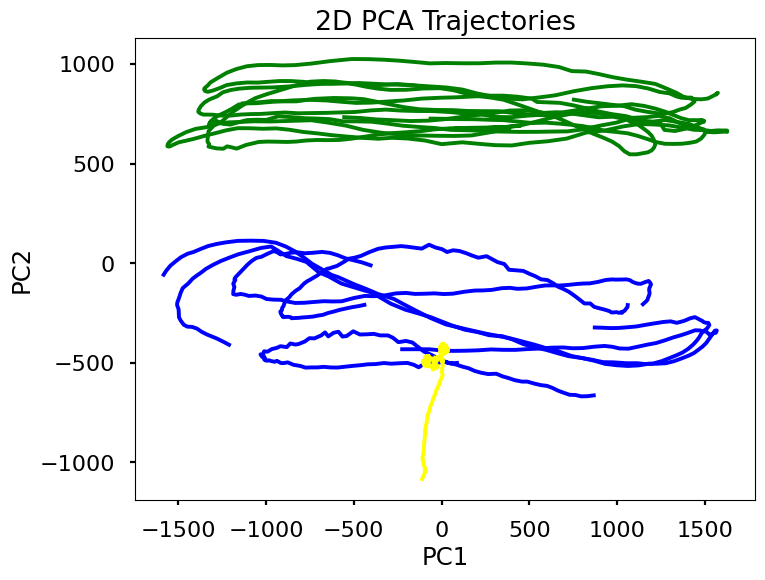

In [ ]:
import plotly
import plotly.graph_objs as go

# Task 2
# Truncate the PCA modes set to 2 and 3 modes and plot the projected 𝑋𝑡𝑟𝑎𝑖𝑛 in the truncated PCA
# space as low dimensional 2D (PC1,PC2 coordinates) and 3D (PC1,PC2,PC3 coordinates) trajectories.
# Use colors for different movements and discuss visualization and your findings.

mean = pca.mean_.reshape(-1, 1)
PC2_coordinates = pca.components_[:2, :]
PC3_coordinates = pca.components_[:3, :]
Projections2D = {}
Projections3D = {}
for file_name in files:
    aux_vals = np.load(os.path.join(folder, file_name))
    aux_vals_centered = aux_vals - mean

    proj2D = PC2_coordinates @ aux_vals_centered
    proj3D = PC3_coordinates @ aux_vals_centered

    category = ""
    if "walking" in file_name:
        category = "walking"
    elif "running" in file_name:
        category = "running"
    else:
        category = "jumping"

    if category not in Projections2D:
        Projections2D[category] = []
    Projections2D[category].append(proj2D)
    if category not in Projections3D:
        Projections3D[category] = []
    Projections3D[category].append(proj3D)

colors = {"walking" : "blue", "running" : "green", "jumping" : "yellow"}

plt.figure(figsize=(8,6))
for category in Projections2D:
    category_projections = Projections2D[category]
    for projection in category_projections:
        plt.plot(projection[0], projection[1], color = colors[category], label = category)
plt.title("2D PCA Trajectories")
plt.xlabel("PC1")
plt.ylabel("PC2")

fig = go.Figure()
for category in Projections2D:
    category_projections = Projections3D[category]
    for projection in category_projections:
      fig.add_trace(go.Scatter3d(x=projection[0],y=projection[1],z=projection[2],
      mode='lines', line=dict(color=colors[category],width=5)))
fig.show()



In [ ]:
# 3. In order to classify each sample with type of movement establish the following ground truth. Create a
# vector of ground truth labels with an integer per class, e.g., 0 (walking), 1 (jumping), 2 (running) and
# assign an appropriate label to each sample in 𝑋𝑡𝑟𝑎𝑖𝑛. Then for each movement compute its centroid
# (mean) in 𝑘-modes PCA space.
# Task 3: ground-truth labels (one per FILE / sample)

ground_truth_labels = []
for file_name in files:
    if "walking" in file_name: ground_truth_labels.append(0)
    elif "jumping" in file_name: ground_truth_labels.append(1)
    else: ground_truth_labels.append(2)
ground_truth_labels = np.array(ground_truth_labels)

labels_to_indexes = {"walking" : 0, "jumping" : 1, "running" : 2}

centroids2 = {}
for category in Projections2D:
    mean_points = []
    category_projections = Projections2D[category]
    for projection in category_projections:
        mean_points.append(np.mean(projection, axis=1))
    centroid = np.mean(mean_points, axis=0)
    centroids2[labels_to_indexes[category]] = centroid

centroids3 = {}
for category in Projections3D:
    mean_points = []
    category_projections = Projections3D[category]
    for projection in category_projections:
        mean_points.append(np.mean(projection, axis=1))
    centroid = np.mean(mean_points, axis=0)
    centroids3[labels_to_indexes[category]] = centroid


In [ ]:
# 4. Having the ground truth, preform the following training. Create another vector of trained labels. To
# assign these labels, for each sample in 𝑋𝑡𝑟𝑎𝑖𝑛 compute the distance between the projected point in
# 𝑘-modes PCA space and each of the centroids. The minimal distance will determine to which class
# the sample belongs. Assign the label of the class of the centroid with minimal distance in the trained
# labels vector. Compute the trained labels for various 𝑘 values of 𝑘-PCA truncation and report the
# accuracy of the trained classifier (the percentage of samples for which the ground truth and the trained
# labels match). You can use accuracy_score function in 𝑠𝑘𝑙𝑒𝑎𝑟𝑛 for this purpose. Discuss your results
# in terms of optimal 𝑘 for the classifier accuracy.
from sklearn.metrics import accuracy_score

centroids = {2:centroids2, 3:centroids3}

def predict_k(k, folder_name, file_list):
    PCk = pca.components_[:k, :]
    y_pred = []
    aux_centroids = centroids[k]
    for file_name in file_list:
        aux_vals = np.load(os.path.join(folder_name, file_name))
        point = (PCk @ (aux_vals - mean)).mean(axis=1)
        closest_label = None
        closest_distance = float('inf')
        for centroid in aux_centroids:
            distance = np.linalg.norm(point - aux_centroids[centroid])
            if distance < closest_distance:
                closest_distance = distance
                closest_centroid = centroid
        y_pred.append(closest_centroid)
    return np.array(y_pred)

train_pred2 = predict_k(2, folder, files)
train_pred3 = predict_k(3, folder, files)

print("train accuracy of k=2 dimension:", accuracy_score(ground_truth_labels, train_pred2))
print("train accuracy of k=3 dimension:", accuracy_score(ground_truth_labels, train_pred3))


train accuracy of k=2 dimension: 0.9333333333333333
train accuracy of k=3 dimension: 0.8


In [ ]:
# To test how the classification performs on classification/recognition of new samples, load the given test
# samples and for each test sample assign the ground truth label. By projecting onto 𝑘-PCA space and
# computing the distance to the centroids, predict the test labels. Report the accuracy of the classifier
# on the test samples. Discuss and compare it with trained accuracy. Try various 𝑘 values.
test_folder = "/content/drive/MyDrive/AMATH482HW2_test"
test_files = [file_name for file_name in os.listdir(test_folder) if file_name.endswith(".npy")]

test_pred2 = predict_k(2, test_folder, test_files)
test_pred3 = predict_k(3, test_folder, test_files)

test_ground_truth_labels = []
for file_name in test_files:
    if "walking" in file_name: test_ground_truth_labels.append(0)
    elif "jumping" in file_name: test_ground_truth_labels.append(1)
    else: test_ground_truth_labels.append(2)
test_ground_truth_labels = np.array(test_ground_truth_labels)

print("test accuracy of k=2 dimension:", accuracy_score(test_ground_truth_labels, test_pred2))
print("test accuracy of k=3 dimension:", accuracy_score(test_ground_truth_labels, test_pred3))

test accuracy of k=2 dimension: 1.0
test accuracy of k=3 dimension: 1.0
